# Product Recommandation Engine

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print ("Imported required modules/libraries")

Imported required modules/libraries


## 1. Read and explore the given dataset. ( Rename column/add headers, plot histograms, find data characteristics)

In [2]:
org_df = pd.read_csv("ratings_Electronics.csv",header=None,names = ['user_id','product_id','ratings','timestamp'])
print ("\nShape of the data:")
print ('\033[1mTotal Rows:\033[0m',org_df.shape[0])
print ('\033[1mTotal Columns:\033[0m',org_df.shape[1])
print ("\033[1mReading the data from .csv file and printing first 5 lines:\033[0m")
org_df.head()


Shape of the data:
Total Rows: 7824482
Total Columns: 4
Reading the data from .csv file and printing first 5 lines:


,user_id,product_id,ratings,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


In [3]:
print ("\033[1mAction Performed:\033[0m")
print ("*"*50)
print ("1) \033[1mDropped 'timestamp' column\033[0m as its not used for our analytics")
org_df.drop("timestamp",axis=1,inplace=True)
print ("\nShape of the data after dropping timestamp:")
print ('\033[1mTotal Rows:\033[0m',org_df.shape[0])
print ('\033[1mTotal Columns:\033[0m',org_df.shape[1])
print ("\033[1mReading the data from .csv file and printing first 5 lines:\033[0m")
org_df.head()

Action Performed:
**************************************************
1) Dropped 'timestamp' column as its not used for our analytics

Shape of the data after dropping timestamp:
Total Rows: 7824482
Total Columns: 3
Reading the data from .csv file and printing first 5 lines:


,user_id,product_id,ratings
0,AKM1MP6P0OYPR,0132793040,5.0
1,A2CX7LUOHB2NDG,0321732944,5.0
2,A2NWSAGRHCP8N5,0439886341,1.0
3,A2WNBOD3WNDNKT,0439886341,3.0
4,A1GI0U4ZRJA8WN,0439886341,1.0


In [4]:
print ('\033[1mDatatypes of the columns:\033[0m')
print (org_df.info())
print ("\n\033[1mInference:\033[0m")
print ("1) There are 3 Columns with \033[1m'user_id'\033[0m column of type \033[1mOBJECT\033[0m, \033[1m'product_id' \
\033[0m as \033[1mOBJECT\033[0m and 'ratings' as \033[1mFLOAT\033[0m values as well\n2) The dataset is of \
size \033[1mmore than 179 MB\033[0m")

Datatypes of the columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7824482 entries, 0 to 7824481
Data columns (total 3 columns):
 #   Column      Dtype  
---  ------      -----  
 0   user_id     object 
 1   product_id  object 
 2   ratings     float64
dtypes: float64(1), object(2)
memory usage: 179.1+ MB
None

Inference:
1) There are 3 Columns with 'user_id' column of type OBJECT, 'product_id'  as OBJECT and 'ratings' as FLOAT values as well
2) The dataset is of size more than 179 MB


In [5]:
print ("\n\033[1mInference:\033[0m")
print ('*'*50)
print ("\033[1mNo Outliers (or) Incorrect values\033[0m seems to be found \
in \033[1mratings columns\033[0m")
org_df.describe().transpose()


Inference:
**************************************************
No Outliers (or) Incorrect values seems to be found in ratings columns


,count,mean,std,min,25%,50%,75%,max
ratings,7824482.0,4.012337,1.38091,1.0,3.0,5.0,5.0,5.0


In [6]:
print ("\n\033[1mInference:\033[0m")
print ('*'*50)
print ("\033[1mNo NULL values\033[0m seems to be found \
in \033[1mUSER_ID, PRODUCT_ID and RATINGS columns\033[0m")
pd.DataFrame(org_df.isnull().sum(), columns = ['NULL COUNT'])


Inference:
**************************************************
No NULL values seems to be found in USER_ID, PRODUCT_ID and RATINGS columns


,NULL COUNT
user_id,0
product_id,0
ratings,0


In [7]:
print ("\n\033[1mInference:\033[0m")
print ('*'*50)
print ("1) \033[1m4 Million\033[0m unique USERS and \033[1maround 0.5 Million\033[0m unique PRODUCTS found in the dataset")
pd.DataFrame(org_df.nunique(), columns = ['UNIQUE COUNT'])


Inference:
**************************************************
1) 4 Million unique USERS and around 0.5 Million unique PRODUCTS found in the dataset


,UNIQUE COUNT
user_id,4201696
product_id,476002
ratings,5



Inference:
**************************************************
1) More than 50% of products rated 5 which is more than 4 Million
2) Rest of the ratings contribute remaining 50% of data


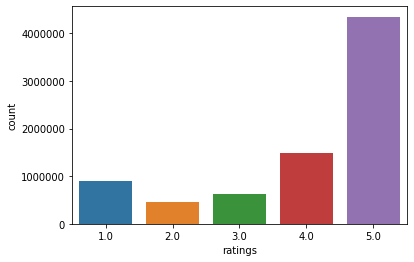

In [8]:
print ("\n\033[1mInference:\033[0m")
print ('*'*50)
print ("1) \033[1mMore than 50%\033[0m of products rated 5 which is more than 4 Million\n\
2) Rest of the ratings contribute remaining 50% of data")
sns.countplot(org_df['ratings']);

## 2. Take a subset of the dataset to make it less sparse/ denser. ( For example, keep the users only who has given 50 or more number of ratings )

In [9]:
print ("\n\033[1mAction Performed:\033[0m")
print ('*'*50)
print ("1) \033[1mGROUP BY on USERS Performed\033[0m\n2) The USERS who has\
provided \033[1m50 or more ratings\033[0m has been picked to reduce data size")
usr_grp = org_df.groupby("user_id")
usr_rat_cnt_df = usr_grp[['ratings']].count().reset_index()
usr_rat_cnt_df_50 = usr_rat_cnt_df[usr_rat_cnt_df['ratings']>=50]
usr_rat_cnt_df_50.columns = ['user_id','user_ratings_cnt']


Action Performed:
**************************************************
1) GROUP BY on USERS Performed
2) The USERS who hasprovided 50 or more ratings has been picked to reduce data size


In [10]:
print ("\n\033[1mAction Performed:\033[0m")
print ('*'*50)
print ("USER details who has provided \033[1m50 or more ratings\033[0m has been pulled up using INNER join")
usr_50_df = pd.merge(org_df,usr_rat_cnt_df_50,on=['user_id'],how='inner')[['user_id','product_id','ratings','user_ratings_cnt']]


Action Performed:
**************************************************
USER details who has provided 50 or more ratings has been pulled up using INNER join


In [11]:
print ("\nShape of the data for users who provided 50 or more ratings:")
print ('\033[1mTotal Rows:\033[0m',usr_50_df.shape[0])
print ('\033[1mTotal Columns:\033[0m',usr_50_df.shape[1])
print ("\033[1mReading the data from .csv file and printing first 5 lines:\033[0m")
usr_50_df.head()


Shape of the data for users who provided 50 or more ratings:
Total Rows: 125871
Total Columns: 4
Reading the data from .csv file and printing first 5 lines:


,user_id,product_id,ratings,user_ratings_cnt
0,A3BY5KCNQZXV5U,0594451647,5.0,50
1,A3BY5KCNQZXV5U,B00000JD4V,4.0,50
2,A3BY5KCNQZXV5U,B000063574,5.0,50
3,A3BY5KCNQZXV5U,B0000CDJP8,5.0,50
4,A3BY5KCNQZXV5U,B0007Y794O,5.0,50



Inference:
**************************************************
1) More than 56% of products rated 5 which is more than 70k
2) Rest of the ratings contribute remaining 44% of data


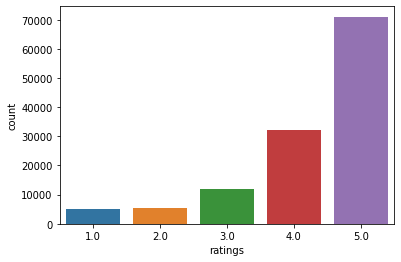

In [12]:
print ("\n\033[1mInference:\033[0m")
print ('*'*50)
print ("1) \033[1mMore than 56%\033[0m of products rated 5 which is more than 70k\n\
2) Rest of the ratings contribute remaining 44% of data")
sns.countplot(usr_50_df['ratings']);

In [13]:
print ("\n\033[1mInference:\033[0m")
print ('*'*50)
print ("1) \033[1m1540\033[0m unique USERS who has provided 50 or more ratings \
and \033[1maround 50k \033[0m unique PRODUCTS among them found in the dataset")
pd.DataFrame(usr_50_df[['user_id','product_id','ratings']].nunique(), columns = ['UNIQUE COUNT'])


Inference:
**************************************************
1) 1540 unique USERS who has provided 50 or more ratings and around 50k  unique PRODUCTS among them found in the dataset


,UNIQUE COUNT
user_id,1540
product_id,48190
ratings,5


In [14]:
print ("\n\033[1mAction Performed:\033[0m")
print ('*'*50)
print ("1) \033[1mGROUP BY on PRODUCTS Performed\033[0m\n2) The PRODUCTS which has\
\033[1m 5000 or more ratings\033[0m has been picked to pick more popular products from prominent users")
prd_grp = org_df.groupby('product_id')
prd_rat_cnt_df = prd_grp[['ratings']].count().reset_index()
prd_rat_cnt_df_50 = prd_rat_cnt_df[prd_rat_cnt_df['ratings']>=5000]
prd_rat_cnt_df_50.columns = ['product_id','product_ratings_cnt']


Action Performed:
**************************************************
1) GROUP BY on PRODUCTS Performed
2) The PRODUCTS which has 5000 or more ratings has been picked to pick more popular products from prominent users


In [15]:
print ("\n\033[1mAction Performed:\033[0m")
print ('*'*50)
print ("PRODUCT details which has 5000 and more ratings has been pulled up using INNER join")
usr_prd_50_df = pd.merge(usr_50_df,prd_rat_cnt_df_50,on=['product_id'],how='inner')[['user_id','product_id','ratings','user_ratings_cnt','product_ratings_cnt']]
usr_prd_50_df.head(20)


Action Performed:
**************************************************
PRODUCT details which has 5000 and more ratings has been pulled up using INNER join


,user_id,product_id,ratings,user_ratings_cnt,product_ratings_cnt
0,A3BY5KCNQZXV5U,B009A5204K,4.0,50,7059
1,A32HSNCNPRUMTR,B009A5204K,4.0,72,7059
2,A3OZA8HNJM26DC,B009A5204K,5.0,54,7059
3,A2PK64OVZA1U8Z,B009A5204K,4.0,82,7059
4,A21NS06GDEA3V0,B009A5204K,5.0,59,7059
5,A37IRE9GZ0CZ7I,B009A5204K,5.0,97,7059
6,A18OTCHQ6MXD6X,B009A5204K,5.0,73,7059
7,AETQIN7OH0RL9,B009A5204K,3.0,54,7059
8,A1NQFT941TOTT7,B009A5204K,2.0,56,7059
9,A3BY5KCNQZXV5U,B00BGGDVOO,4.0,50,6893


In [16]:
print ("\n\033[1mInference:\033[0m")
print ('*'*50)
print ("1) \033[1m841\033[0m unique USERS who has provided 50 or more ratings \
and \033[1maround 27 \033[0m unique PRODUCTS with 5k ratings")
pd.DataFrame(usr_prd_50_df[['user_id','product_id','ratings']].nunique(), columns = ['UNIQUE COUNT'])


Inference:
**************************************************
1) 841 unique USERS who has provided 50 or more ratings and around 27  unique PRODUCTS with 5k ratings


,UNIQUE COUNT
user_id,841
product_id,27
ratings,5


## 3. Build Popularity Recommender model.

In [17]:
print ("\n\033[1mAction Performed:\033[0m")
print ('*'*50)
print ("\t1) Building the \033[1mpopularity based data based on USERS with 25 or more \
ratings and PRODUCTS with 5000 or more ratings\033[0m")
popular_df = usr_prd_50_df.groupby('product_id')
pd.DataFrame(popular_df['ratings'].mean().sort_values(ascending=False).head(10))


Action Performed:
**************************************************
	1) Building the popularity based data based on USERS with 25 or more ratings and PRODUCTS with 5000 or more ratings


,ratings
product_id,
B00316263Y,4.868421
B003ES5ZUU,4.864130
B0019EHU8G,4.855556
B002WE6D44,4.770000
B007R5YDYA,4.769231
B007WTAJTO,4.701220
B0098F5W0Q,4.666667
B003LR7ME6,4.647059
B0002L5R78,4.611940


In [18]:
print ("\n\033[1mAction Performed:\033[0m")
print ('*'*50)
print ("\t1) Top PRODUCTS in terms of \033[1mCOUNT of RATINGS\033[0m")
pd.DataFrame(popular_df['product_ratings_cnt'].mean().sort_values(ascending=False).head(10))


Action Performed:
**************************************************
	1) Top PRODUCTS in terms of COUNT of RATINGS


,product_ratings_cnt
product_id,
B0074BW614,18244
B00DR0PDNE,16454
B007WTAJTO,14172
B0019EHU8G,12285
B006GWO5WK,12226
B003ELYQGG,11617
B003ES5ZUU,10276
B007R5YDYA,9907
B00622AG6S,9823


In [19]:
from surprise.model_selection import train_test_split
from surprise import Dataset
from surprise import Reader
from surprise import KNNWithMeans, accuracy
from surprise import SVD
print ("Imported required modules/libraries from surprise")

Imported required modules/libraries from surprise


In [20]:
print ("\n\033[1mAction Performed:\033[0m")
print ('*'*50)
print ("\033[1mUSER details\033[0m who has provided \033[1m50 or more ratings\033[0m has been pulled up using INNER join")
print ("Displaying first 5 records")
usr_grp = org_df.groupby("user_id")
usr_rat_cnt_df = usr_grp[['ratings']].count().reset_index()
usr_rat_cnt_df_50 = usr_rat_cnt_df[usr_rat_cnt_df['ratings']>=50]
usr_rat_cnt_df_50.columns = ['user_id','usr_cnt']
usr_50_df = pd.merge(org_df,usr_rat_cnt_df_50,on=['user_id'],how='inner')[['user_id','product_id','ratings','usr_cnt']]
df = usr_50_df.iloc[:,:-1].copy()
df.head()


Action Performed:
**************************************************
USER details who has provided 50 or more ratings has been pulled up using INNER join
Displaying first 5 records


,user_id,product_id,ratings
0,A3BY5KCNQZXV5U,0594451647,5.0
1,A3BY5KCNQZXV5U,B00000JD4V,4.0
2,A3BY5KCNQZXV5U,B000063574,5.0
3,A3BY5KCNQZXV5U,B0000CDJP8,5.0
4,A3BY5KCNQZXV5U,B0007Y794O,5.0


In [21]:
print ("\n\033[1mAction Performed:\033[0m")
print ('*'*50)
print ("We get \033[1m125871 records of USERS with 50 or more ratings\033[0m")
df.describe().transpose()


Action Performed:
**************************************************
We get 125871 records of USERS with 50 or more ratings


,count,mean,std,min,25%,50%,75%,max
ratings,125871.0,4.261339,1.062144,1.0,4.0,5.0,5.0,5.0


## 4. Split the data randomly into a train and test dataset. ( For example, split it in 70/30 ratio)

In [22]:
print ("\n\033[1mAction Performed:\033[0m")
print ('*'*50)
print ("1) Created \033[1mobject for reader\033[0m to read DataFrame and create a dataset.\n2)TRAIN TEST Split\
done with \033[1m70:30 ratio using surprise library\033[0m")
reader = Reader(rating_scale=(1, 5))
data_set = Dataset.load_from_df(df,reader)
train, test = train_test_split(data_set, test_size = 0.3,random_state=101)


Action Performed:
**************************************************
1) Created object for reader to read DataFrame and create a dataset.
2)TRAIN TEST Splitdone with 70:30 ratio using surprise library


## 5. Build Collaborative Filtering model.

In [23]:
print ("\n\033[1mAction Performed:\033[0m")
print ('*'*50)
print ("1) Identified \033[1m50 neighbours using KNNWithMeans and 'Pearson Correlation'\033[0m \
is used in identifying the neighbours\n2) The \033[1mtraining and testing\033[0m of the data is performed\n\
3) Applied \033[1mSVD on the TRAIN and TEST Data\033[0m\n")
algo_knn = KNNWithMeans(k=50,sim_options = {'name': 'pearson_baseline','user_based': True})
algo_knn.fit(train)
pred_knn = algo_knn.test(test)

algo_svd = SVD()
algo_svd.fit(train)
pred_svd = algo_svd.test(test)


Action Performed:
**************************************************
1) Identified 50 neighbours using KNNWithMeans and 'Pearson Correlation' is used in identifying the neighbours
2) The training and testing of the data is performed
3) Applied SVD on the TRAIN and TEST Data

Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.


In [24]:
print ("\n\033[1mAction Performed:\033[0m")
print ('*'*50)
print ("\t\033[1mPredicted Results of KNN\033[0m displayed with \033[1mESTIMATED values, \
Actual number of Neighbours, Was able to predict flag along with USER and PRODUCT details\033[0m")
pred_knn[:20]


Action Performed:
**************************************************
	Predicted Results of KNN displayed with ESTIMATED values, Actual number of Neighbours, Was able to predict flag along with USER and PRODUCT details


[Prediction(uid='A1XXMNLOLKNO0I', iid='B0006SE3K4', r_ui=5.0, est=4.262424950913074, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'}),
 Prediction(uid='A3JV071KO43Q5X', iid='B004XC6GJ0', r_ui=5.0, est=3.74468085106383, details={'actual_k': 0, 'was_impossible': False}),
 Prediction(uid='AUBEFRFHJR64Y', iid='B005Y1FM9O', r_ui=1.0, est=4.262424950913074, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'}),
 Prediction(uid='A1GWG5CWLKJ7ET', iid='B0068ALVAO', r_ui=1.0, est=4.294117647058823, details={'actual_k': 0, 'was_impossible': False}),
 Prediction(uid='ASJZT7DM51QEM', iid='B0043CVH2Q', r_ui=3.0, est=3.658333333333333, details={'actual_k': 1, 'was_impossible': False}),
 Prediction(uid='A64LEAZ2QF8L2', iid='B00065L5SU', r_ui=5.0, est=4.262424950913074, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'}),
 Prediction(uid='A16HXVNPU5TCGE', iid='B00E42U1UE', r_ui=5.0, est=4.262424950913074, details={'was_impossible'

In [25]:
print ("\n\033[1mAction Performed:\033[0m")
print ('*'*50)
print ("\t\033[1mPredicted Results of SVD\033[0m displayed with \033[1mESTIMATED values, \
Actual number of Neighbours, Was able to predict flag along with USER and PRODUCT details\033[0m")
pred_svd[:20]


Action Performed:
**************************************************
	Predicted Results of SVD displayed with ESTIMATED values, Actual number of Neighbours, Was able to predict flag along with USER and PRODUCT details


[Prediction(uid='A1XXMNLOLKNO0I', iid='B0006SE3K4', r_ui=5.0, est=4.769219948619032, details={'was_impossible': False}),
 Prediction(uid='A3JV071KO43Q5X', iid='B004XC6GJ0', r_ui=5.0, est=4.220533966643696, details={'was_impossible': False}),
 Prediction(uid='AUBEFRFHJR64Y', iid='B005Y1FM9O', r_ui=1.0, est=3.9770494343411844, details={'was_impossible': False}),
 Prediction(uid='A1GWG5CWLKJ7ET', iid='B0068ALVAO', r_ui=1.0, est=3.985291972154458, details={'was_impossible': False}),
 Prediction(uid='ASJZT7DM51QEM', iid='B0043CVH2Q', r_ui=3.0, est=3.8815768801774344, details={'was_impossible': False}),
 Prediction(uid='A64LEAZ2QF8L2', iid='B00065L5SU', r_ui=5.0, est=4.840930102345731, details={'was_impossible': False}),
 Prediction(uid='A16HXVNPU5TCGE', iid='B00E42U1UE', r_ui=5.0, est=4.665333192472492, details={'was_impossible': False}),
 Prediction(uid='A3PCEB9ND82AGE', iid='B00FFCB0BG', r_ui=5.0, est=4.804424180229585, details={'was_impossible': False}),
 Prediction(uid='A206CGM6J75UJY',

## 6. Evaluate the above model. ( Once the model is trained on the training data, it can be used to compute the error (like RMSE) on redictions made on the test data.) You can also use a different method to evaluate the models.

In [26]:
print ("\n\033[1mAction Performed:\033[0m")
print ('*'*50)
print ("1) The \033[1maccuracy\033[0m of KNNWithMeans and SVD \
\033[1m on TEST data\033[0m predictions calculated \033[1musing RMSE\033[0m \n")
print ('KNNWithMeans, SVD')
accuracy.rmse(pred_knn),accuracy.rmse(pred_svd)


Action Performed:
**************************************************
1) The accuracy of KNNWithMeans and SVD  on TEST data predictions calculated using RMSE 

KNNWithMeans, SVD
RMSE: 1.0578
RMSE: 0.9905


(1.0577601726102683, 0.9905105112771012)

In [27]:
from surprise.model_selection import cross_validate
print ("\n\033[1mAction Performed:\033[0m")
print ('*'*50)
print ("\033[1m****KNNWithMeans:\033[0m")
print ("1) \033[1m10 fold Cross Validation\033[0m performed on the dataset \n2) Gathered \033[1m'TEST_RMSE','TRAIN_RMSE',\
'TEST_MAE','TRAIN_MAE','FIT_TIME','TEST_TIME' metrics\033[0m for validation\n")
cv_knn = cross_validate(algo_knn, data_set, measures=['RMSE', 'MAE'], cv=10, verbose=False,return_train_measures=True)
cv_knn = pd.DataFrame(cv_knn)
cv_knn['ALGORITHM']='KNNWithMeans'
cv_knn.columns = ['TEST_RMSE','TRAIN_RMSE','TEST_MAE','TRAIN_MAE','FIT_TIME','TEST_TIME','ALGORITHM']
cv_knn


Action Performed:
**************************************************
****KNNWithMeans:
1) 10 fold Cross Validation performed on the dataset 
2) Gathered 'TEST_RMSE','TRAIN_RMSE','TEST_MAE','TRAIN_MAE','FIT_TIME','TEST_TIME' metrics for validation

Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pear

,TEST_RMSE,TRAIN_RMSE,TEST_MAE,TRAIN_MAE,FIT_TIME,TEST_TIME,ALGORITHM
0,1.059988,0.028073,0.771750,0.009431,1.293027,0.454906,KNNWithMeans
1,1.057380,0.028262,0.771979,0.009463,1.200557,0.352913,KNNWithMeans
2,1.069364,0.028167,0.776488,0.009480,1.224277,0.380701,KNNWithMeans
3,1.043582,0.027918,0.762318,0.009362,1.770541,0.793741,KNNWithMeans
4,1.067966,0.027944,0.773341,0.009391,1.159155,0.353340,KNNWithMeans
5,1.041619,0.027965,0.761924,0.009426,1.204578,0.372033,KNNWithMeans
6,1.062713,0.028254,0.770414,0.009515,1.175869,0.475021,KNNWithMeans
7,1.061376,0.027788,0.776352,0.009364,1.175808,0.472874,KNNWithMeans
8,1.054103,0.027939,0.768723,0.009471,1.187631,0.386901,KNNWithMeans
9,1.065478,0.028195,0.771587,0.009460,1.157177,0.357154,KNNWithMeans


In [28]:
from surprise.model_selection import cross_validate
print ("\n\033[1mAction Performed:\033[0m")
print ('*'*50)
print ("\033[1m****SVD:\033[0m")
print ("1) \033[1m10 fold Cross Validation\033[0m performed on the dataset \n2) Gathered \033[1m'TEST_RMSE','TRAIN_RMSE',\
'TEST_MAE','TRAIN_MAE','FIT_TIME','TEST_TIME' metrics\033[0m for validation\n")
algo_svd = SVD()
cv_svd = cross_validate(algo_svd, data_set, measures=['RMSE', 'MAE'], cv=10, verbose=False,return_train_measures=True)
cv_svd = pd.DataFrame(cv_svd)
cv_svd['ALGORITHM']='SVD'
cv_svd.columns = ['TEST_RMSE','TRAIN_RMSE','TEST_MAE','TRAIN_MAE','FIT_TIME','TEST_TIME','ALGORITHM']
cv_svd


Action Performed:
**************************************************
****SVD:
1) 10 fold Cross Validation performed on the dataset 
2) Gathered 'TEST_RMSE','TRAIN_RMSE','TEST_MAE','TRAIN_MAE','FIT_TIME','TEST_TIME' metrics for validation



,TEST_RMSE,TRAIN_RMSE,TEST_MAE,TRAIN_MAE,FIT_TIME,TEST_TIME,ALGORITHM
0,0.966545,0.692890,0.715901,0.514437,9.806289,0.124995,SVD
1,0.974338,0.693242,0.720738,0.514991,9.690696,0.140622,SVD
2,0.985907,0.692506,0.733219,0.513979,9.610640,0.125825,SVD
3,0.994291,0.691817,0.737243,0.513588,9.892617,0.140617,SVD
4,0.992246,0.691676,0.730774,0.513783,9.877100,0.140614,SVD
5,0.976211,0.693292,0.722426,0.514823,9.564054,0.156731,SVD
6,0.968859,0.691844,0.714635,0.514030,9.516737,0.139814,SVD
7,0.986479,0.691158,0.725026,0.513569,9.814531,0.140617,SVD
8,0.984747,0.691987,0.727988,0.514164,9.784365,0.140623,SVD
9,0.987217,0.691402,0.723142,0.513746,11.163287,0.125008,SVD


In [29]:
print ("\n\033[1mAction Performed:\033[0m")
print ('*'*50)
print ("1) The USERS who has provided \033[1m200 or more ratings\033[0m picked to \
\033[1mavoid MEMORY ISSUE\033[0m\n2) DATASET \
created with \033[1mrating scale 1 to 5\033[0m\n3) TRAINSET created using \033[1m'build_full_trainset'\033[0m")
usr_grp = org_df.groupby("user_id")
usr_rat_cnt_df = usr_grp[['ratings']].count().reset_index()
usr_rat_cnt_df_200 = usr_rat_cnt_df[usr_rat_cnt_df['ratings']>=200]
usr_rat_cnt_df_200.columns = ['user_id','usr_cnt']
usr_200_df = pd.merge(org_df,usr_rat_cnt_df_200,on=['user_id'],how='inner')[['user_id','product_id','ratings','usr_cnt']]
df = usr_200_df.iloc[:,:-1].copy()
reader = Reader(rating_scale=(1, 5))
data_set = Dataset.load_from_df(df,reader)
trainset = data_set.build_full_trainset()


Action Performed:
**************************************************
1) The USERS who has provided 200 or more ratings picked to avoid MEMORY ISSUE
2) DATASET created with rating scale 1 to 5
3) TRAINSET created using 'build_full_trainset'


In [30]:
print ("\n\033[1mAction Performed:\033[0m")
print ('*'*50)
print ("1) TESTSET created \033[1musing 'build_anti_testset'\033[0m\n2) \033[1mAlgorithms \
(KNNWithMeans, SVD) trained \033[0m\
using the TRAIN set\n3) \033[1mPredictions done\033[0m using the TEST set using KNNWithMeans, SVD\n")
testset = trainset.build_anti_testset()
algo_knn.fit(trainset)
pred_knn = algo_knn.test(testset)

algo_svd.fit(trainset)
pred_svd = algo_svd.test(testset)


Action Performed:
**************************************************
1) TESTSET created using 'build_anti_testset'
2) Algorithms (KNNWithMeans, SVD) trained using the TRAIN set
3) Predictions done using the TEST set using KNNWithMeans, SVD

Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.


In [31]:
print ("\n\033[1mAction Performed:\033[0m")
print ('*'*50)
print ("1) DELETED unwanted variables \033[1mto save SPACE and MEMORY\033[0m")
del org_df, usr_50_df


Action Performed:
**************************************************
1) DELETED unwanted variables to save SPACE and MEMORY


In [32]:
print ("\n\033[1mAction Performed:\033[0m")
print ('*'*50)
print ("1) \033[1mKNNWithMeans and SVD Predicted values converted \
into a dataframe\033[0m for easy manipulations and processing")
print ("\n\033[1m*****************Processing Progress of KNNWithMeans DataFrame*******************\033[0m")
import datetime as dt
d={}
uid = []
iid = []
r_ui = []
est = []
actual_k =[]
was_impossible =[]
for i,vals in enumerate(pred_knn):
    pred_arr = np.array(pred_knn[i])
    uid.append(pred_arr[0])
    iid.append(pred_arr[1])
    r_ui.append(pred_arr[2])
    est.append(pred_arr[3])
    actual_k.append(pred_arr[4]['actual_k'])
    was_impossible.append(pred_arr[4]['was_impossible'])
    if ((i == 50000) or (i == 100000) or (i == 200000) or (i == 300000) or 
        (i == 350000) or (i == 400000) or (i == 500000) or (i == 550000) or (i == 600000) or (i==len(pred_knn)-1)):
        print ("{0} Records Processed @{1}".format(i,dt.datetime.now()))

d['uid'] = uid
d['iid'] = iid
d['r_ui'] = r_ui
d['est'] = est
d['actual_k'] = actual_k
d['was_impossible'] = was_impossible
d['Algorithm']='KNNWithMeans'
pred_knn_df = pd.DataFrame(d, index = list(range(0,len(pred_knn)))) 

print ("\n\033[1m*****************Processing Progress of SVD DataFrame*******************\033[0m")
d={}
uid = []
iid = []
r_ui = []
est = []
actual_k =[]
was_impossible =[]
for i,vals in enumerate(pred_svd):
    pred_arr = np.array(pred_svd[i])
    uid.append(pred_arr[0])
    iid.append(pred_arr[1])
    r_ui.append(pred_arr[2])
    est.append(pred_arr[3])
    was_impossible.append(pred_arr[4]['was_impossible'])
    if ((i == 50000) or (i == 100000) or (i == 200000) or (i == 300000) or 
        (i == 350000) or (i == 400000) or (i == 500000) or (i == 550000) or (i == 600000) or (i==len(pred_svd)-1)):
        print ("{0} Records Processed @{1}".format(i,dt.datetime.now()))

d['uid'] = uid
d['iid'] = iid
d['r_ui'] = r_ui
d['est'] = est
d['actual_k'] = None
d['was_impossible'] = was_impossible
d['Algorithm']='SVD'
pred_svd_df = pd.DataFrame(d, index = list(range(0,len(pred_svd)))) 


Action Performed:
**************************************************
1) KNNWithMeans and SVD Predicted values converted into a dataframe for easy manipulations and processing

*****************Processing Progress of KNNWithMeans DataFrame*******************
50000 Records Processed @2021-01-03 01:06:29.851602
100000 Records Processed @2021-01-03 01:06:30.492723
200000 Records Processed @2021-01-03 01:06:31.781397
300000 Records Processed @2021-01-03 01:06:33.085985
350000 Records Processed @2021-01-03 01:06:33.928977
400000 Records Processed @2021-01-03 01:06:34.699246
489133 Records Processed @2021-01-03 01:06:35.840011

*****************Processing Progress of SVD DataFrame*******************
50000 Records Processed @2021-01-03 01:06:37.094899
100000 Records Processed @2021-01-03 01:06:37.692684
200000 Records Processed @2021-01-03 01:06:38.928937
300000 Records Processed @2021-01-03 01:06:40.309896
350000 Records Processed @2021-01-03 01:06:40.967094
400000 Records Processed @2021-01

# 7. Get top - K ( K = 5) recommendations. Since our goal is to recommend new products to each user based on his/her habits, we will recommend 5 new products.

In [33]:
print ("\nShape of the predicted KNNWithMeans DataFrame:")
print ('\033[1mTotal Rows:\033[0m',pred_knn_df.shape[0])
print ('\033[1mTotal Columns:\033[0m',pred_knn_df.shape[1])
print ("\033[1mReading the data from .csv file and printing first 5 lines:\033[0m")
pred_knn_df.head()


Shape of the predicted KNNWithMeans DataFrame:
Total Rows: 489134
Total Columns: 7
Reading the data from .csv file and printing first 5 lines:


,uid,iid,r_ui,est,actual_k,was_impossible,Algorithm
0,A5JLAU2ARJ0BO,1400699169,4.298081,4.515674,1,False,KNNWithMeans
1,A5JLAU2ARJ0BO,B00004SQET,4.298081,4.515674,1,False,KNNWithMeans
2,A5JLAU2ARJ0BO,B00004WCGF,4.298081,4.515674,1,False,KNNWithMeans
3,A5JLAU2ARJ0BO,B000083KIH,4.298081,4.515674,1,False,KNNWithMeans
4,A5JLAU2ARJ0BO,B00009R960,4.298081,4.515674,1,False,KNNWithMeans


In [34]:
print ("\nShape of the predicted SVD DataFrame:")
print ('\033[1mTotal Rows:\033[0m',pred_svd_df.shape[0])
print ('\033[1mTotal Columns:\033[0m',pred_svd_df.shape[1])
print ("\033[1mReading the data from .csv file and printing first 5 lines:\033[0m")
pred_svd_df.head()


Shape of the predicted SVD DataFrame:
Total Rows: 489134
Total Columns: 7
Reading the data from .csv file and printing first 5 lines:


,uid,iid,r_ui,est,actual_k,was_impossible,Algorithm
0,A5JLAU2ARJ0BO,1400699169,4.298081,3.798052,None,False,SVD
1,A5JLAU2ARJ0BO,B00004SQET,4.298081,3.642341,None,False,SVD
2,A5JLAU2ARJ0BO,B00004WCGF,4.298081,4.074080,None,False,SVD
3,A5JLAU2ARJ0BO,B000083KIH,4.298081,3.478371,None,False,SVD
4,A5JLAU2ARJ0BO,B00009R960,4.298081,4.567812,None,False,SVD


In [35]:
print ("\n\033[1mAction Performed:\033[0m")
print ('*'*50)
print ("1) Applied \033[1mRANK for PRODUCTS based on EST ratings predicted using KNNWithMeans for each USER\033[0m")
pred_knn_df['rank'] = pred_knn_df.sort_values(['est'], ascending=False).groupby(['uid']).cumcount() + 1


Action Performed:
**************************************************
1) Applied RANK for PRODUCTS based on EST ratings predicted using KNNWithMeans for each USER


In [36]:
print ("\n\033[1mAction Performed:\033[0m")
print ('*'*50)
print ("1) Applied \033[1mRANK for PRODUCTS based on EST ratings predicted using SVD for each USER\033[0m")
pred_svd_df['rank'] = pred_svd_df.sort_values(['est'], ascending=False).groupby(['uid']).cumcount() + 1


Action Performed:
**************************************************
1) Applied RANK for PRODUCTS based on EST ratings predicted using SVD for each USER


In [37]:
print ("\n\033[1mAction Performed:\033[0m")
print ('*'*50)
print ("1) \033[1mFunction created\033[0m to fetch \033[1mTOP N Products for USERs and Algorithm passed\033[0m")
def return_top_k(usr,k,alg):
    if alg == 'knn':
        return (pred_knn_df[(pred_knn_df['uid']==usr) & (pred_knn_df['rank']<=k)][['uid','iid','est','Algorithm','rank']].sort_values(['rank']))
    else:
        return (pred_svd_df[(pred_svd_df['uid']==usr) & (pred_svd_df['rank']<=k)][['uid','iid','est','Algorithm','rank']].sort_values(['rank']))


Action Performed:
**************************************************
1) Function created to fetch TOP N Products for USERs and Algorithm passed


In [38]:
print ("\n\033[1mAction Performed:\033[0m")
print ('*'*50)
print ("\tListing the \033[1munique USERS\033[0m in the KNN dataframe")
pred_knn_df['uid'].unique()


Action Performed:
**************************************************
	Listing the unique USERS in the KNN dataframe


array(['A5JLAU2ARJ0BO', 'A3PD8JD9L4WEII', 'A1VQHH85U7PX0',
       'A36K2N527TXXJN', 'ADLVFFE4VBT8', 'A250AXLRBVYKB4',
       'A680RUE1FDO8B', 'A3CG93783LP0FO', 'AEJAGHLC675A7',
       'A1T1YSCDW0PD25', 'A6FIAB28IS79', 'AWPODHOB4GFWL',
       'A2NYK9KWFMJV4Y', 'A231WM2Z2JL0U3', 'A1J75JJ0Q2OEJN',
       'A1EH2S92FHWZRP', 'A1F9Z42CFF9IAY', 'A3OXHLG6DIBRW8',
       'A3CW0ZLUO5X2B1', 'A22CW0ZHY3NJH8', 'A3EXWV8FNSSFL6',
       'A38RMU1Y5TDP9', 'A12DQZKRKTNF5E', 'A2BMZRO0H7TFCS',
       'A3LGT6UZL99IW1', 'A11KZ906QD08C5', 'AOEAD7DPLZE53',
       'A31N0XY2UTB25C', 'A203OCQQ12MAVT', 'A23GFTVIETX7DS',
       'AT6CZDCP4TRGA', 'A3OA4DV4L81N1D', 'A2NOW4U7W3F7RI',
       'A1ODOGXEYECQQ8', 'A1EXGL6L0QQ0M5', 'A4WEZJOIZIV4U',
       'A2AY4YUOX2N1BQ', 'A25C2M3QF9G7OQ', 'A1X1CEGHTHMBL1',
       'A1CMD08Z49PGKQ', 'ARBKYIVNYWK3C', 'AGVWTYW0ULXHT',
       'A2XRMQA6PJ5ZJ8', 'A2UOHALGF2X77Q', 'A20DZX38KRBIT8',
       'A3AYSYSLHU26U9', 'A3A4ZAIBQWKOZS', 'A17BUUBOU0598B',
       'AVPNQUVZWMDSX', 'A1UQBFCERIP7VJ

In [39]:
print ("\n\033[1mAction Performed:\033[0m")
print ('*'*50)
print ("\tListing the \033[1munique USERS\033[0m in the SVD dataframe")
pred_svd_df['uid'].unique()


Action Performed:
**************************************************
	Listing the unique USERS in the SVD dataframe


array(['A5JLAU2ARJ0BO', 'A3PD8JD9L4WEII', 'A1VQHH85U7PX0',
       'A36K2N527TXXJN', 'ADLVFFE4VBT8', 'A250AXLRBVYKB4',
       'A680RUE1FDO8B', 'A3CG93783LP0FO', 'AEJAGHLC675A7',
       'A1T1YSCDW0PD25', 'A6FIAB28IS79', 'AWPODHOB4GFWL',
       'A2NYK9KWFMJV4Y', 'A231WM2Z2JL0U3', 'A1J75JJ0Q2OEJN',
       'A1EH2S92FHWZRP', 'A1F9Z42CFF9IAY', 'A3OXHLG6DIBRW8',
       'A3CW0ZLUO5X2B1', 'A22CW0ZHY3NJH8', 'A3EXWV8FNSSFL6',
       'A38RMU1Y5TDP9', 'A12DQZKRKTNF5E', 'A2BMZRO0H7TFCS',
       'A3LGT6UZL99IW1', 'A11KZ906QD08C5', 'AOEAD7DPLZE53',
       'A31N0XY2UTB25C', 'A203OCQQ12MAVT', 'A23GFTVIETX7DS',
       'AT6CZDCP4TRGA', 'A3OA4DV4L81N1D', 'A2NOW4U7W3F7RI',
       'A1ODOGXEYECQQ8', 'A1EXGL6L0QQ0M5', 'A4WEZJOIZIV4U',
       'A2AY4YUOX2N1BQ', 'A25C2M3QF9G7OQ', 'A1X1CEGHTHMBL1',
       'A1CMD08Z49PGKQ', 'ARBKYIVNYWK3C', 'AGVWTYW0ULXHT',
       'A2XRMQA6PJ5ZJ8', 'A2UOHALGF2X77Q', 'A20DZX38KRBIT8',
       'A3AYSYSLHU26U9', 'A3A4ZAIBQWKOZS', 'A17BUUBOU0598B',
       'AVPNQUVZWMDSX', 'A1UQBFCERIP7VJ

In [40]:
print ("\n\033[1mAction Performed:\033[0m")
print ('*'*50)
print ("List of \033[1mTop 10 Suggesstions by KNNWithMeans \033[0m for user \033[1mA36K2N527TXXJN\033[0m:")
print (return_top_k('A36K2N527TXXJN',10,'knn'))

print ("\nList of \033[1mTop 10 Suggesstions by SVD \033[0m for user \033[1mA36K2N527TXXJN\033[0m:")
print (return_top_k('A36K2N527TXXJN',10,'svd'))


Action Performed:
**************************************************
List of Top 10 Suggesstions by KNNWithMeans  for user A36K2N527TXXJN:
                  uid         iid  est     Algorithm  rank
36743  A36K2N527TXXJN  B003FP41ES  5.0  KNNWithMeans     1
36714  A36K2N527TXXJN  B00166YXN2  5.0  KNNWithMeans     2
36716  A36K2N527TXXJN  B0019QPBUS  5.0  KNNWithMeans     3
36717  A36K2N527TXXJN  B001BSTJIO  5.0  KNNWithMeans     4
36718  A36K2N527TXXJN  B001DMEYCY  5.0  KNNWithMeans     5
36719  A36K2N527TXXJN  B001DSIMAI  5.0  KNNWithMeans     6
36721  A36K2N527TXXJN  B001F0MFXY  5.0  KNNWithMeans     7
36722  A36K2N527TXXJN  B001FWYU9E  5.0  KNNWithMeans     8
36723  A36K2N527TXXJN  B001KC0818  5.0  KNNWithMeans     9
36727  A36K2N527TXXJN  B001R4BTLC  5.0  KNNWithMeans    10

List of Top 10 Suggesstions by SVD  for user A36K2N527TXXJN:
                  uid         iid       est Algorithm  rank
30143  A36K2N527TXXJN  B00G4UQ6U8  5.000000       SVD     1
28888  A36K2N527TXXJN  B001TH

In [41]:
print ("\n\033[1mAction Performed:\033[0m")
print ('*'*50)
print ("List of \033[1mTop 10 Suggesstions by KNNWithMeans \033[0m for user \033[1mA203OCQQ12MAVT\033[0m:")
print (return_top_k('A203OCQQ12MAVT',10,'knn'))

print ("\nList of \033[1mTop 10 Suggesstions by SVD \033[0m for user \033[1mA203OCQQ12MAVT\033[0m:")
print (return_top_k('A203OCQQ12MAVT',10,'svd'))


Action Performed:
**************************************************
List of Top 10 Suggesstions by KNNWithMeans  for user A203OCQQ12MAVT:
                   uid         iid  est     Algorithm  rank
272020  A203OCQQ12MAVT  B004NY9V0O  5.0  KNNWithMeans     1
271119  A203OCQQ12MAVT  B00JVOTUGQ  5.0  KNNWithMeans     2
271124  A203OCQQ12MAVT  B0006PK8IS  5.0  KNNWithMeans     3
271134  A203OCQQ12MAVT  B000M19LES  5.0  KNNWithMeans     4
271135  A203OCQQ12MAVT  B000NWNK7U  5.0  KNNWithMeans     5
271136  A203OCQQ12MAVT  B000O8SKZ0  5.0  KNNWithMeans     6
271138  A203OCQQ12MAVT  B000TKHGL2  5.0  KNNWithMeans     7
271144  A203OCQQ12MAVT  B001144JQU  5.0  KNNWithMeans     8
271151  A203OCQQ12MAVT  B001COE6QC  5.0  KNNWithMeans     9
271155  A203OCQQ12MAVT  B001HBIT7C  5.0  KNNWithMeans    10

List of Top 10 Suggesstions by SVD  for user A203OCQQ12MAVT:
                   uid         iid  est Algorithm  rank
266982  A203OCQQ12MAVT  B005CLPP8E  5.0       SVD     1
268556  A203OCQQ12MAVT  B0

## 8. Summarise your insights.


Summary:
**************************************************
Best Recommender: SVD

SVD Reasoning: 
1) The below boxplot clearly shows SVD has better TEST RMSE score compared to KNN.
2) The TEST RMSE range of SVD is lower than that of minimum RMSE of KNN.
3) Similar to RMSE, MAE too is low for SVD than KNN.
4) Though the FIT time is higher for SVD, TEST time is lower than KNN.
5) The below value counts shows that NOT much neighbours found for each user in KNN.

    Number of Neighbours
0                 241402
1                 210226
2                  26306
3                   6745
4                   2411
5                    974
6                    532
7                    283
8                    146
9                     57
10                    41
11                     9
12                     2

6) No intersections found in the recommendations suggested by KNN and SVD.

List of Top 10 Suggesstions by KNNWithMeans  for user A203OCQQ12MAVT:
                   uid         iid  e

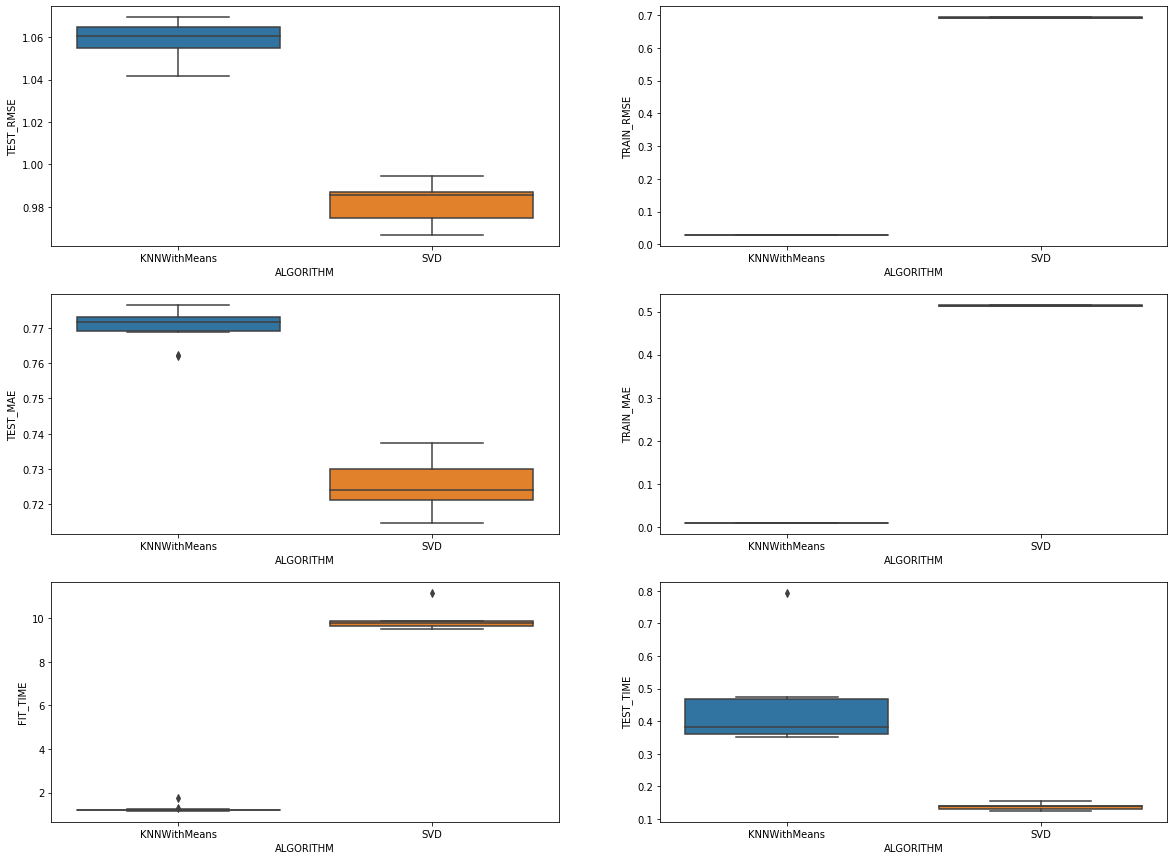

In [42]:
print ("\n\033[1mSummary:\033[0m")
print ('*'*50)
cv_df = pd.concat([cv_knn,cv_svd])
print ("\033[1mBest Recommender: SVD\033[0m")
print ("\n\033[1mSVD Reasoning: \033[0m")
print ("1) The below boxplot clearly shows \033[1mSVD has better TEST RMSE score\033[0m compared to KNN.\n\
2) The \033[1mTEST RMSE range of SVD is lower than that of minimum RMSE of KNN.\033[0m\n\
3) Similar to RMSE, \033[1mMAE too is low for SVD\033[0m than KNN.\n\
4) Though the \033[1mFIT time is higher for SVD, TEST time is lower than KNN.\033[0m\n\
5) The below value counts shows that \033[1mNOT much neighbours found for each user in KNN.\033[0m\n")

k_count_df = pd.DataFrame(pred_knn_df['actual_k'].value_counts())
k_count_df.columns = ['Number of Neighbours']
print (k_count_df)

print ("\n6) \033[1mNo intersections found\033[0m in the recommendations suggested by KNN and SVD.\n")
print ("List of \033[1mTop 10 Suggesstions by KNNWithMeans \033[0m for user \033[1mA203OCQQ12MAVT\033[0m:")
print (return_top_k('A203OCQQ12MAVT',10,'knn'))

print ("\nList of \033[1mTop 10 Suggesstions by SVD \033[0m for user \033[1mA203OCQQ12MAVT\033[0m:")
print (return_top_k('A203OCQQ12MAVT',10,'svd'))

fig = plt.figure(figsize=(20,15))
plt.subplot(3,2,1)
sns.boxplot(x=cv_df['ALGORITHM'],y=cv_df['TEST_RMSE']);
plt.subplot(3,2,2)
sns.boxplot(x=cv_df['ALGORITHM'],y=cv_df['TRAIN_RMSE']);
plt.subplot(3,2,3)
sns.boxplot(x=cv_df['ALGORITHM'],y=cv_df['TEST_MAE']);
plt.subplot(3,2,4)
sns.boxplot(x=cv_df['ALGORITHM'],y=cv_df['TRAIN_MAE']);
plt.subplot(3,2,5)
sns.boxplot(x=cv_df['ALGORITHM'],y=cv_df['FIT_TIME']);
plt.subplot(3,2,6)
sns.boxplot(x=cv_df['ALGORITHM'],y=cv_df['TEST_TIME']);